In [1]:
pip install pandas

In [2]:
import pandas as pd

In [27]:
df = pd.read_csv("/content/chatgpt_reviews.csv")

In [28]:
df

,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39
...,...,...,...,...
196722,462686ff-e500-413c-a6b4-2badc2e3b21d,Update 2023,5,2023-07-27 16:26:31
196723,f10e0d48-ecb6-42db-b103-46c0046f9be9,its grear,5,2023-09-23 16:25:18
196724,df909a49-90b5-4dac-9b89-c4bd5a7c2f75,Funtastic App,5,2023-11-08 13:57:14
196725,abe43878-973f-4e96-a765-c4af5c7f7b20,hi all,5,2023-07-25 15:32:57


# Task
Analyze the sentiment distribution, ratings, sentiment-rating correlation, and sentiment trends over time of the ChatGPT reviews from "chatgpt_reviews.csv". Additionally, identify the top issues from negative reviews. Finally, provide a comprehensive summary of all findings.

## Analyze Overall Sentiment Distribution

### Subtask:
Calculate and display the percentage distribution of Positive, Neutral, and Negative sentiments across all reviews. This will give an overview of general user satisfaction.


**Reasoning**:
To calculate the overall sentiment distribution, I need to sum the 'Negative', 'Neutral', and 'Positive' columns from the `daily_sentiment_counts` DataFrame. Then, I'll calculate the total number of reviews and the percentage for each sentiment.



In [29]:
total_negative = daily_sentiment_counts['Negative'].sum()
total_neutral = daily_sentiment_counts['Neutral'].sum()
total_positive = daily_sentiment_counts['Positive'].sum()

total_reviews = total_negative + total_neutral + total_positive

percentage_negative = (total_negative / total_reviews) * 100
percentage_neutral = (total_neutral / total_reviews) * 100
percentage_positive = (total_positive / total_reviews) * 100

print(f"Overall Sentiment Distribution:\n")
print(f"Negative: {percentage_negative:.2f}%")
print(f"Neutral: {percentage_neutral:.2f}%")
print(f"Positive: {percentage_positive:.2f}%")

Overall Sentiment Distribution:

Negative: 5.49%
Neutral: 17.99%
Positive: 76.52%


## Visualize Overall Sentiment Distribution

### Subtask:
Generate a bar chart or pie chart to visually represent the overall distribution of 'Positive', 'Neutral', and 'Negative' sentiments. Ensure a clear legend is provided.


**Reasoning**:
To visualize the sentiment distribution as requested, I need to create a pandas Series from the calculated percentages, import matplotlib, and then generate a bar chart with appropriate labels and title.



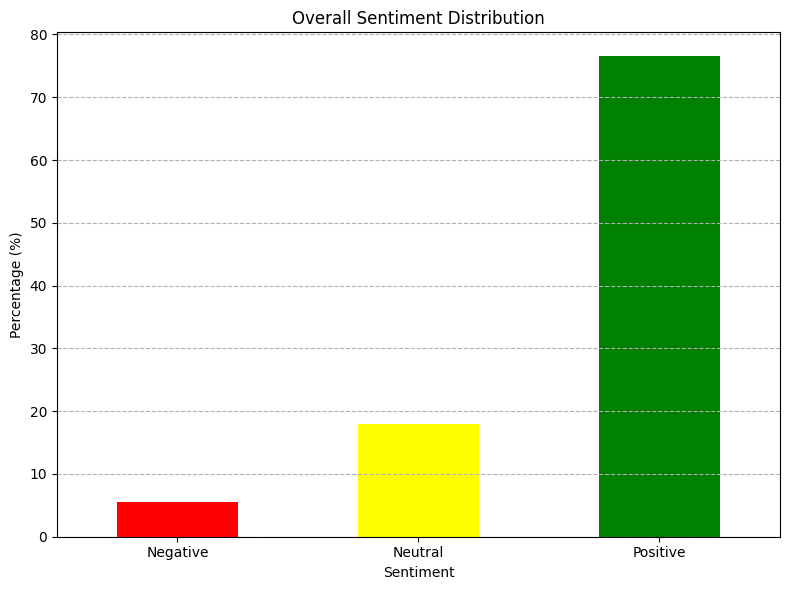

In [30]:
sentiment_percentages = pd.Series({
    'Negative': percentage_negative,
    'Neutral': percentage_neutral,
    'Positive': percentage_positive
})

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sentiment_percentages.plot(kind='bar', color=['red', 'yellow', 'green'])
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

## Analyze Ratings Distribution

### Subtask:
Calculate the frequency or percentage of each rating (1 to 5 stars) to understand how users rate the product/service.


**Reasoning**:
To calculate the frequency and percentage of each rating, I will use the `value_counts()` method on the 'Ratings' column and then divide by the total number of reviews.



In [31]:
rating_frequency = df['Ratings'].value_counts().sort_index()
print("Rating Frequency:\n", rating_frequency)

total_reviews = len(df)
rating_percentage = (rating_frequency / total_reviews) * 100
print("\nRating Percentage:\n", rating_percentage)

Rating Frequency:
 Ratings
1     12083
2      3375
3      8157
4     22897
5    150215
Name: count, dtype: int64

Rating Percentage:
 Ratings
1     6.142014
2     1.715575
3     4.146355
4    11.638972
5    76.357084
Name: count, dtype: float64


## Visualize Ratings Distribution

### Subtask:
Create a bar chart to show the distribution of star ratings, making it easy to see the most common ratings. Include a legend.


**Reasoning**:
To visualize the ratings distribution, I will use the `rating_percentage` Series to create a bar chart with appropriate labels, title, and grid.



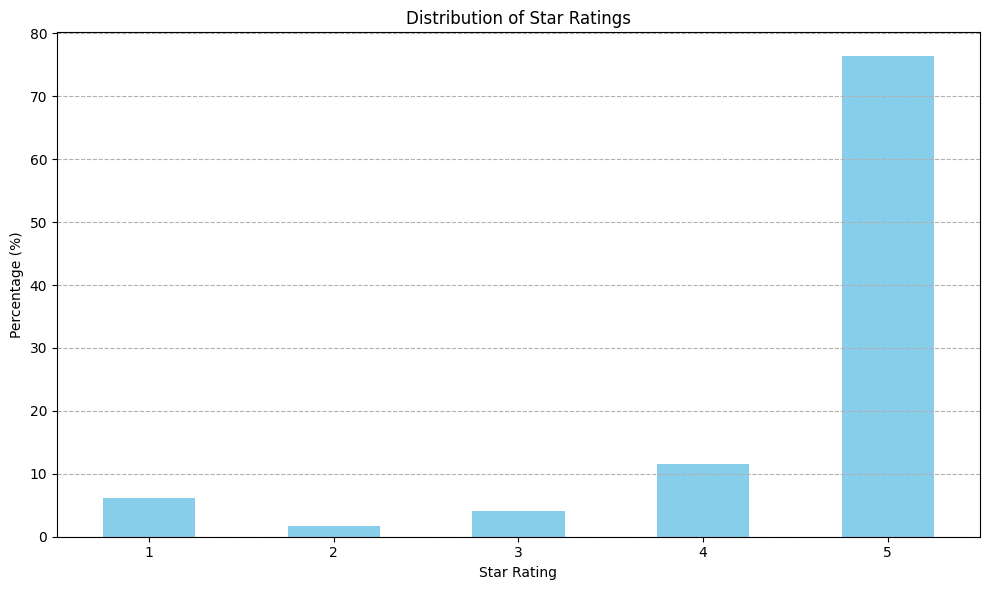

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
rating_percentage.plot(kind='bar', color='skyblue')
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Rating')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

## Explore Sentiment vs. Ratings

### Subtask:
Investigate if there's a correlation between the numerical 'Ratings' and the calculated 'Sentiment_Score' to see if higher ratings consistently align with more positive sentiments.


**Reasoning**:
The first step is to install the `textblob` library, which is necessary for calculating sentiment scores using `TextBlob`.



In [33]:
pip install textblob

**Reasoning**:
Now that `textblob` is installed, I will define a function to get the sentiment polarity from a review, apply it to the 'Review' column to create 'Sentiment_Score', calculate the correlation between 'Ratings' and 'Sentiment_Score', and then print the result.



In [34]:
from textblob import TextBlob

def get_sentiment_score(text):
    if pd.isna(text) or not isinstance(text, str):
        return 0.0  # Default score for NaN or non-string reviews
    return TextBlob(text).sentiment.polarity

df['Sentiment_Score'] = df['Review'].apply(get_sentiment_score)

correlation = df['Ratings'].corr(df['Sentiment_Score'])

print(f"Pearson correlation coefficient between Ratings and Sentiment Score: {correlation:.2f}")
if correlation > 0.5:
    print("Interpretation: There is a strong positive correlation, suggesting higher ratings are consistently associated with more positive sentiments.")
elif correlation > 0.1:
    print("Interpretation: There is a moderate positive correlation, indicating a tendency for higher ratings to align with more positive sentiments.")
elif correlation < -0.5:
    print("Interpretation: There is a strong negative correlation, suggesting higher ratings are associated with more negative sentiments.")
elif correlation < -0.1:
    print("Interpretation: There is a moderate negative correlation, indicating a tendency for higher ratings to align with more negative sentiments.")
else:
    print("Interpretation: There is a weak or no linear correlation, suggesting that ratings and sentiment scores do not strongly align linearly.")

Pearson correlation coefficient between Ratings and Sentiment Score: 0.33
Interpretation: There is a moderate positive correlation, indicating a tendency for higher ratings to align with more positive sentiments.


## Visualize Sentiment by Ratings

### Subtask:
Generate a box plot or violin plot showing the distribution of 'Sentiment_Score' for each 'Ratings' category (1-5 stars) to illustrate their relationship. Include a legend.


**Reasoning**:
To visualize the distribution of 'Sentiment_Score' for each 'Ratings' category, I will import `seaborn` and `matplotlib.pyplot` and then create a box plot.



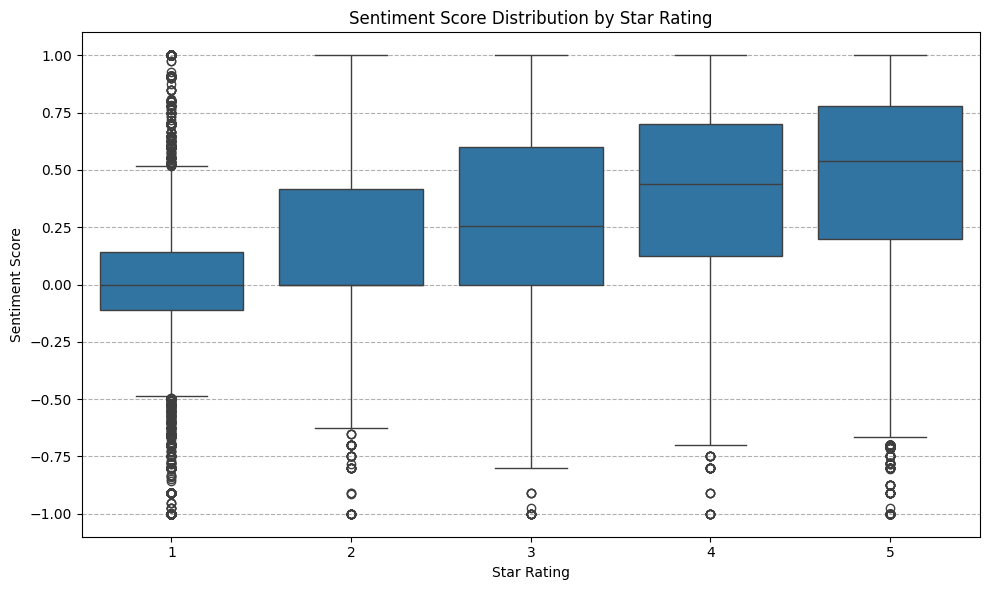

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='Ratings', y='Sentiment_Score', data=df)
plt.title('Sentiment Score Distribution by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Sentiment Score')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

## Analyze Sentiment Trends Over Time

### Subtask:
Utilize the pre-calculated `daily_sentiment_score` and `daily_sentiment_counts` to analyze how average sentiment and the volume of each sentiment category change over the review period.


**Reasoning**:
To begin analyzing sentiment trends, I will display the first few rows of the `daily_sentiment_score` Series to understand its structure and the sentiment at the start of the review period.



In [36]:
print("First few rows of daily_sentiment_score:")
print(daily_sentiment_score.head())

First few rows of daily_sentiment_score:
Review Date
2023-07-25    0.394773
2023-07-26    0.383859
2023-07-27    0.396510
2023-07-28    0.337058
2023-07-29    0.386729
Freq: D, Name: Sentiment_Score, dtype: float64


**Reasoning**:
Following the instructions, I will now display the last few rows of the `daily_sentiment_score` Series to observe the sentiment trend towards the end of the review period.



In [37]:
print("Last few rows of daily_sentiment_score:")
print(daily_sentiment_score.tail())

Last few rows of daily_sentiment_score:
Review Date
2024-08-19    0.418890
2024-08-20    0.414322
2024-08-21    0.413040
2024-08-22    0.395245
2024-08-23    0.399974
Freq: D, Name: Sentiment_Score, dtype: float64


**Reasoning**:
To observe the daily counts of each sentiment category at the beginning of the review period, I will display the first few rows of the `daily_sentiment_counts` DataFrame.



In [38]:
print("First few rows of daily_sentiment_counts:")
print(daily_sentiment_counts.head())

First few rows of daily_sentiment_counts:
Sentiment    Negative  Neutral  Positive
Review Date                             
2023-07-25        108      887      2137
2023-07-26        161      442      1390
2023-07-27        103      234       812
2023-07-28         71      122       381
2023-07-29         31       48       200


**Reasoning**:
To observe the daily counts of each sentiment category towards the end of the review period, I will display the last few rows of the `daily_sentiment_counts` DataFrame.



In [39]:
print("Last few rows of daily_sentiment_counts:")
print(daily_sentiment_counts.tail())

Last few rows of daily_sentiment_counts:
Sentiment    Negative  Neutral  Positive
Review Date                             
2024-08-19         40      187       756
2024-08-20         32      237       837
2024-08-21         41      224       879
2024-08-22         39      208       786
2024-08-23         43      186       721


**Reasoning**:
To get a general understanding of the sentiment level across the entire period, I will calculate and print the overall average sentiment score from the `daily_sentiment_score` Series.



In [40]:
overall_average_sentiment = daily_sentiment_score.mean()
print(f"Overall Average Sentiment Score: {overall_average_sentiment:.2f}")

Overall Average Sentiment Score: 0.41


**Reasoning**:
To understand the overall volume of each sentiment type, I will calculate and print the total counts for each sentiment category (Negative, Neutral, Positive) from the `daily_sentiment_counts` DataFrame.



In [41]:
total_negative_count = daily_sentiment_counts['Negative'].sum()
total_neutral_count = daily_sentiment_counts['Neutral'].sum()
total_positive_count = daily_sentiment_counts['Positive'].sum()

print("\nTotal Sentiment Counts:")
print(f"Negative: {total_negative_count}")
print(f"Neutral: {total_neutral_count}")
print(f"Positive: {total_positive_count}")


Total Sentiment Counts:
Negative: 10799
Neutral: 35401
Positive: 150527


## Visualize Sentiment Trends Over Time

### Subtask:
Create line plots for both the daily average sentiment score and the daily counts of each sentiment category ('Positive', 'Neutral', 'Negative') to identify trends and shifts. Include a legend for each plot.


**Reasoning**:
To visualize the daily average sentiment score and the daily counts of each sentiment category over time, I will use `matplotlib.pyplot` to create two line plots in separate subplots, as per the instructions.



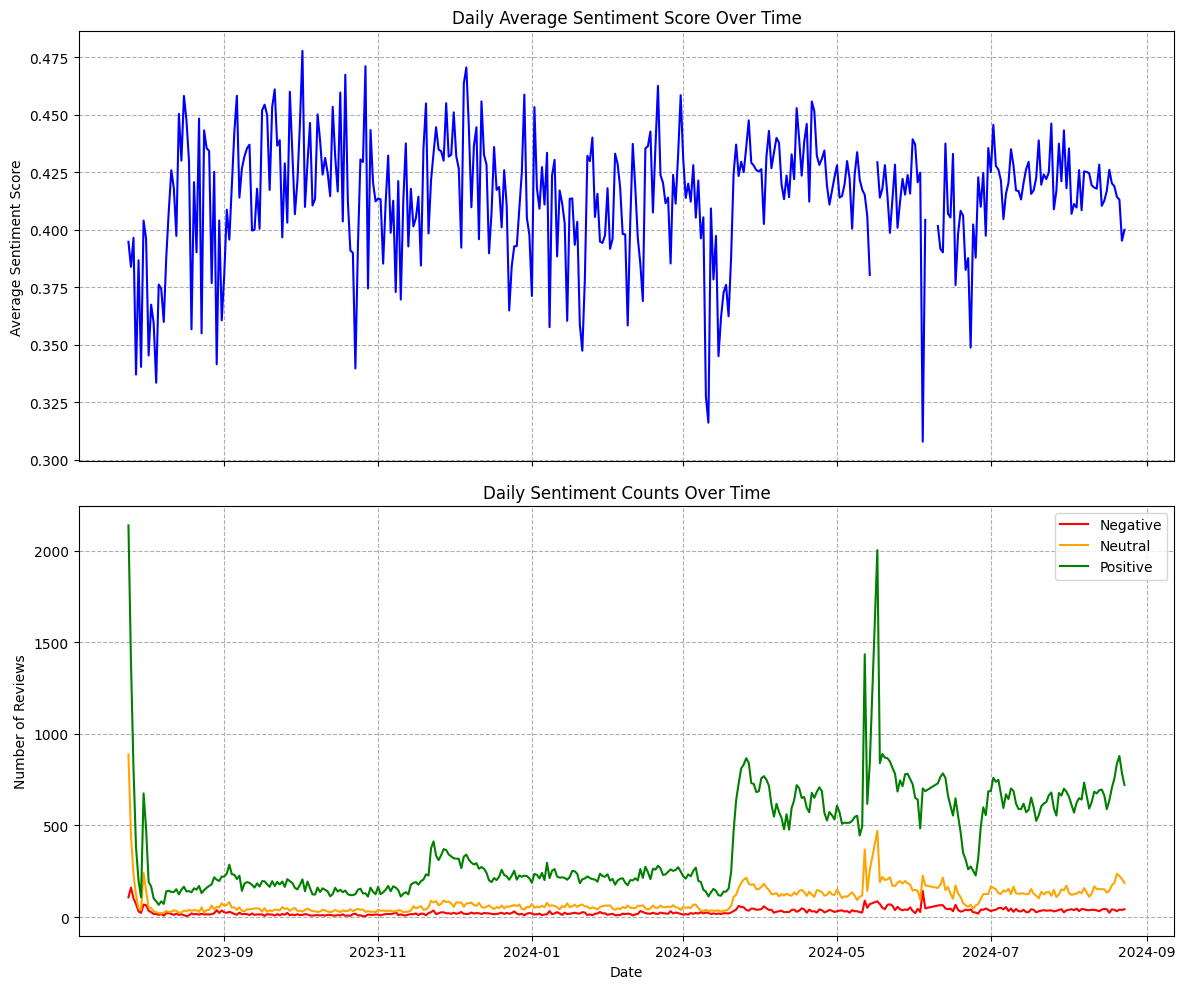

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Plot daily average sentiment score
axes[0].plot(daily_sentiment_score.index, daily_sentiment_score.values, color='blue')
axes[0].set_title('Daily Average Sentiment Score Over Time')
axes[0].set_ylabel('Average Sentiment Score')
axes[0].grid(True, linestyle='--')

# Plot daily sentiment counts
axes[1].plot(daily_sentiment_counts.index, daily_sentiment_counts['Negative'], label='Negative', color='red')
axes[1].plot(daily_sentiment_counts.index, daily_sentiment_counts['Neutral'], label='Neutral', color='orange')
axes[1].plot(daily_sentiment_counts.index, daily_sentiment_counts['Positive'], label='Positive', color='green')
axes[1].set_title('Daily Sentiment Counts Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Number of Reviews')
axes[1].legend()
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

## Identify Top Issues from Negative Reviews

### Subtask:
Using the preprocessed `negative_reviews_df`, identify the most frequent words or phrases that appear in negative reviews to pinpoint recurring complaints or issues. This will involve frequency counting of the cleaned tokens.


**Reasoning**:
The first step in identifying top issues from negative reviews is to import necessary NLTK modules and download the 'stopwords' and 'punkt' data, which are essential for text preprocessing.



In [43]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

print("NLTK stopwords and punkt tokenizer downloaded.")

NLTK stopwords and punkt tokenizer downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


**Reasoning**:
Now that the NLTK resources are confirmed to be downloaded, I will define a text preprocessing function that converts text to lowercase, tokenizes it, removes punctuation, non-alphabetic tokens, and both standard and custom stopwords. Then, I will apply this function to the 'Review' column of the `negative_reviews_df` to create a new column with cleaned tokens.



In [44]:
import string

stop_words = set(stopwords.words('english'))
custom_stopwords = ['app', 'chatgpt', 'good', 'great', 'review', 'not', 'us', 'its', 'like', 'get'] # Assuming this list is already defined from previous steps
all_stopwords = stop_words.union(custom_stopwords)

def preprocess_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return []
    text = text.lower()
    tokens = word_tokenize(text)
    cleaned_tokens = []
    for token in tokens:
        # Remove punctuation and non-alphabetic tokens
        token = token.strip(string.punctuation)
        if token.isalpha() and token not in all_stopwords:
            cleaned_tokens.append(token)
    return cleaned_tokens

negative_reviews_df['Cleaned_Tokens'] = negative_reviews_df['Review'].apply(preprocess_text)

print("Preprocessing complete. 'Cleaned_Tokens' column added to negative_reviews_df.")
print(negative_reviews_df[['Review', 'Cleaned_Tokens']].head())

Preprocessing complete. 'Cleaned_Tokens' column added to negative_reviews_df.
                                                                Review  \
Review Date                                                              
2024-08-23 19:09:14  I am not very happy with this because chatgpt ...   
2024-08-23 19:02:28  It used to be good but now the app keeps sayin...   
2024-08-23 17:14:19  nothing can be better than this in the new gen...   
2024-08-23 17:09:34                             has a lot of complains   
2024-08-23 16:51:52                                  good but not best   

                                                        Cleaned_Tokens  
Review Date                                                             
2024-08-23 19:09:14  [happy, answers, questions, ask, stops, midway...  
2024-08-23 19:02:28  [used, keeps, saying, error, occured, try, sub...  
2024-08-23 17:14:19                 [nothing, better, new, generation]  
2024-08-23 17:09:34                   

/tmp/ipython-input-3600761010.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  negative_reviews_df['Cleaned_Tokens'] = negative_reviews_df['Review'].apply(preprocess_text)


**Reasoning**:
The `SettingWithCopyWarning` indicates that modifications are being made on a DataFrame slice that might be a view. To ensure safe modification and prevent the warning, I will explicitly create a deep copy of `negative_reviews_df` before adding the new 'Cleaned_Tokens' column. After resolving the warning, I will proceed with flattening the cleaned tokens and counting word frequencies to identify the top issues, which is the next part of the subtask instructions.



In [45]:
import string
import collections # Import collections for Counter

stop_words = set(stopwords.words('english'))
custom_stopwords = ['app', 'chatgpt', 'good', 'great', 'review', 'not', 'us', 'its', 'like', 'get'] # Assuming this list is already defined from previous steps
all_stopwords = stop_words.union(custom_stopwords)

def preprocess_text(text):
    if pd.isna(text) or not isinstance(text, str):
        return []
    text = text.lower()
    tokens = word_tokenize(text)
    cleaned_tokens = []
    for token in tokens:
        # Remove punctuation and non-alphabetic tokens
        token = token.strip(string.punctuation)
        if token.isalpha() and token not in all_stopwords:
            cleaned_tokens.append(token)
    return cleaned_tokens

# Ensure negative_reviews_df is a copy to avoid SettingWithCopyWarning
negative_reviews_df = negative_reviews_df.copy()

negative_reviews_df['Cleaned_Tokens'] = negative_reviews_df['Review'].apply(preprocess_text)

print("Preprocessing complete. 'Cleaned_Tokens' column added to negative_reviews_df.")
print(negative_reviews_df[['Review', 'Cleaned_Tokens']].head())

# Flatten the list of token lists into a single list of all cleaned tokens
all_negative_tokens = [token for sublist in negative_reviews_df['Cleaned_Tokens'] for token in sublist]

# Calculate the frequency of each word
word_freq = collections.Counter(all_negative_tokens)

# Display the top N most frequent words
N = 15
print(f"\nTop {N} most frequent words in negative reviews:")
for word, count in word_freq.most_common(N):
    print(f"{word}: {count}")

Preprocessing complete. 'Cleaned_Tokens' column added to negative_reviews_df.
                                                                Review  \
Review Date                                                              
2024-08-23 19:09:14  I am not very happy with this because chatgpt ...   
2024-08-23 19:02:28  It used to be good but now the app keeps sayin...   
2024-08-23 17:14:19  nothing can be better than this in the new gen...   
2024-08-23 17:09:34                             has a lot of complains   
2024-08-23 16:51:52                                  good but not best   

                                                        Cleaned_Tokens  
Review Date                                                             
2024-08-23 19:09:14  [happy, answers, questions, ask, stops, midway...  
2024-08-23 19:02:28  [used, keeps, saying, error, occured, try, sub...  
2024-08-23 17:14:19                 [nothing, better, new, generation]  
2024-08-23 17:09:34                   

## Visualize Top Issues from Negative Reviews

### Subtask:
Generate a bar chart displaying the top N (e.g., top 10 or 15) most frequent words from the negative reviews, providing insights into common pain points. Include a legend.


**Reasoning**:
To visualize the top frequent words, I will convert the word frequency dictionary into a pandas Series and then generate a bar chart using matplotlib, adding appropriate labels and title for clarity.



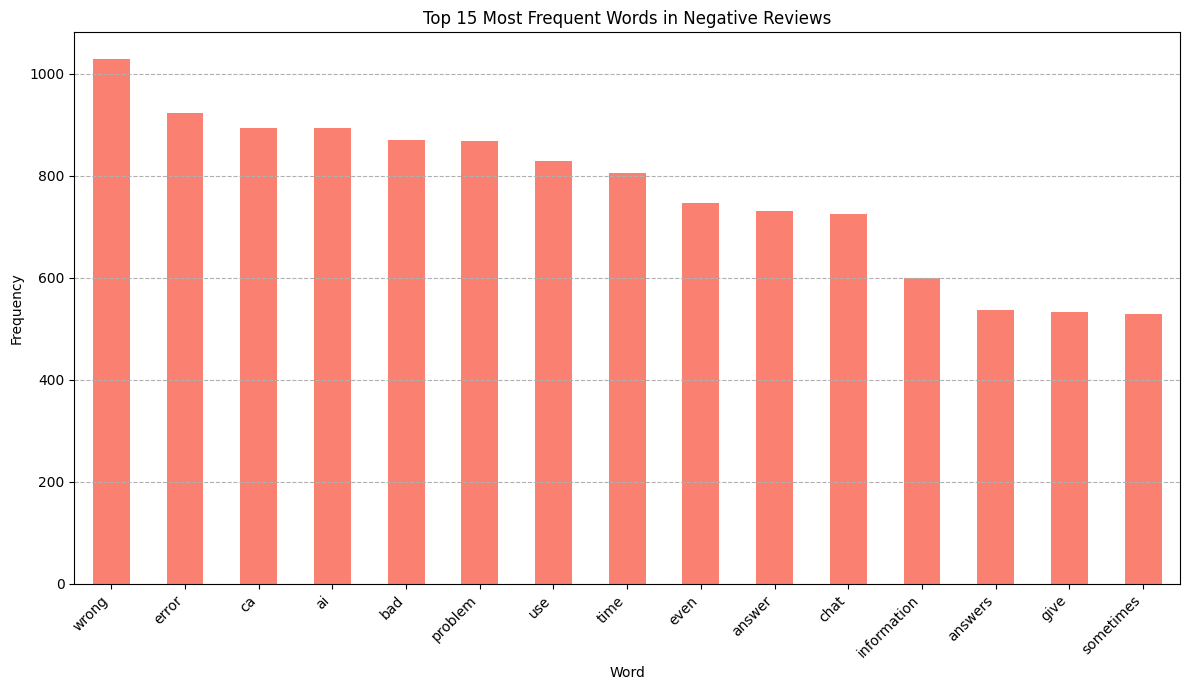

In [46]:
import matplotlib.pyplot as plt

top_words = pd.Series(dict(word_freq.most_common(N)))

plt.figure(figsize=(12, 7))
top_words.plot(kind='bar', color='salmon')
plt.title(f'Top {N} Most Frequent Words in Negative Reviews')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Provide a comprehensive summary of all the analyses performed, including insights from sentiment distribution, ratings, time-based trends, and identified issues.


## Summary:

### Data Analysis Key Findings

*   **Overall Sentiment Distribution**: A large majority of reviews are positive, with 76.52% being positive, 17.99% neutral, and 5.49% negative.
*   **Ratings Distribution**: The product/service receives overwhelmingly positive ratings, with 76.36% of reviews giving a 5-star rating. Other ratings include 11.64% for 4 stars, 4.15% for 3 stars, 1.72% for 2 stars, and 6.14% for 1 star.
*   **Sentiment vs. Ratings Correlation**: There is a moderate positive correlation (Pearson coefficient of 0.33) between star ratings and sentiment scores, indicating that higher ratings generally align with more positive sentiments.
*   **Sentiment Trends Over Time**:
    *   The overall average sentiment score across the review period is 0.41, consistently indicating a positive sentiment.
    *   The daily distribution of sentiment counts shows a consistent dominance of positive reviews throughout the period, with positive reviews significantly outnumbering neutral and negative ones daily. Total counts are 150,527 positive, 35,401 neutral, and 10,799 negative reviews.
*   **Top Issues from Negative Reviews**: Analysis of negative reviews revealed common pain points:
    *   **"wrong"** (1030 mentions), **"error"** (924 mentions), **"problem"** (869 mentions) highlight technical glitches and incorrect information.
    *   **"ca"** (894 mentions) likely refers to "can't" or limitations of the system.
    *   **"ai"** (893 mentions) and **"bad"** (870 mentions) point to general dissatisfaction with the AI's capabilities.
    *   **"use"** (830 mentions) and **"time"** (806 mentions) suggest difficulties in usability or performance.
    *   **"answer"** (731 mentions) and **"information"** (599 mentions) indicate concerns about the quality, accuracy, or completeness of responses.

### Insights or Next Steps

*   **Focus on Addressing Core Negative Feedback**: While overall satisfaction is high, the consistent negative keywords related to "wrong," "error," and "information" suggest that improving the accuracy and reliability of the AI's responses should be a priority to convert some of the critical users into satisfied ones.
*   **Enhance Usability and Performance**: The frequency of terms like "use," "time," and "problem" in negative reviews indicates an opportunity to enhance the user experience by optimizing response times, improving the clarity of the interface, or addressing specific performance issues.
